In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset import ECGDataset
import torch
from src.model import (
    CNNAutoencoder,
    TransformerAutoencoder,
    patch_proj,
    patch_proj_inv,
    MAE1D,
    ViT1DEncoder
)
from torch.utils.data import DataLoader

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [4]:
import matplotlib.pyplot as plt

def plot_ecg_window(x, leads=None, title=None):
    """
    x: torch.Tensor or np.ndarray, shape (n_channels, window_size)
    leads: list of lead names for labeling
    """
    if isinstance(x, torch.Tensor):
        x = x.numpy()

    n_channels, window_size = x.shape
    time = np.arange(window_size)

    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(time, x[i], linewidth=1)
        if leads:
            ax.set_ylabel(leads[i])
        ax.grid(True, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Samples")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [5]:
preprocessed_data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_split_path = os.path.join(DATA_DIR, 'input', 'experiment', 'leads_MLII_V1_tst0.25_rd42.json')

# Double channel (MLII + V1)
ds2 = ECGDataset(preprocessed_data_dir, window_size=1024, stride=512,  json_file_path=json_split_path, mode="sliding", split='val')


Loading data for 8 patients from 'val' split...


In [6]:
model_path1 = os.path.join(DATA_DIR, 'output','mae_test.pth', 'mae_epoch1.pt')
model_path2 = os.path.join(DATA_DIR, 'output','mae_test.pth', 'mae_epoch36.pt')

# autoencoder = TransformerAutoencoder(in_channels=2, emb_size=32, patch_size=10, num_layers=1, nhead=2)
# autoencoder = CNNAutoencoder(in_channels=2, latent_dim=64)
# autoencoder_random = CNNAutoencoder(in_channels=2, latent_dim=64)
# encoder = ViT1DEncoder(signal_length=1024, patch_size=16, in_channels=2,
#                            embed_dim=64, depth=4, num_heads=4, mlp_ratio=2.0,
#                            dropout=0.1, max_rel_len=1024, use_cls_token=False)

# mae = MAE1D(encoder=encoder, decoder_embed_dim=64, decoder_depth=2, mask_ratio=0.75)

model1 = TransformerAutoencoder(in_channels=2, emb_size=64, patch_size=32, num_layers=2, nhead=4)
model2 = TransformerAutoencoder(in_channels=2, emb_size=64, patch_size=32, num_layers=2, nhead=4)


model_saved = torch.load(model_path1)
model1.load_state_dict(model_saved["model_state"])
model1.eval()

model_saved = torch.load(model_path2)
model2.load_state_dict(model_saved["model_state"])
model2.eval()

TransformerAutoencoder(
  (encoder_embed): PatchEmbedding1D(
    (proj): Conv1d(2, 64, kernel_size=(32,), stride=(32,))
    (pos_emb_generator): SinusoidalPosEmb()
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAt

In [7]:
ssl_loader = DataLoader(ds2, batch_size=32)
signals, labels = next(iter(ssl_loader))  # shape: [B, C, T]
with torch.no_grad():
    recon1 = model1(labels)  # shape: [B, C, T]
    recon2 = model2(labels)  # shape: [B, C, T]

In [8]:
porj_label = patch_proj(labels, patch_size=32)

In [9]:
mask1 = recon1['mask']
mask_noextra1 = mask1[:, 1:].unsqueeze(-1)
print(mask_noextra1.shape)
x1_masked = porj_label * (1.0 - mask_noextra1)

mask2 = recon2['mask']
mask_noextra2 = mask2[:, 1:].unsqueeze(-1)
x2_masked = porj_label * (1.0 - mask_noextra2)



torch.Size([32, 32, 1])


In [10]:
x1_masked = patch_proj_inv(x1_masked, C=2, patch_size=32)
x2_masked = patch_proj_inv(x2_masked, C=2, patch_size=32)

recon1_signal = patch_proj_inv(recon1['recon'], C=2, patch_size=32)
recon2_signal = patch_proj_inv(recon2['recon'], C=2, patch_size=32)

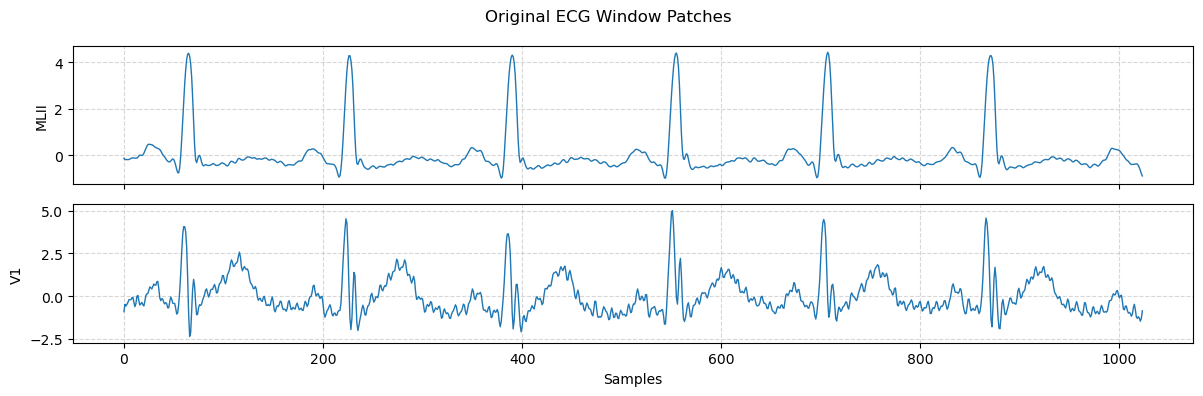

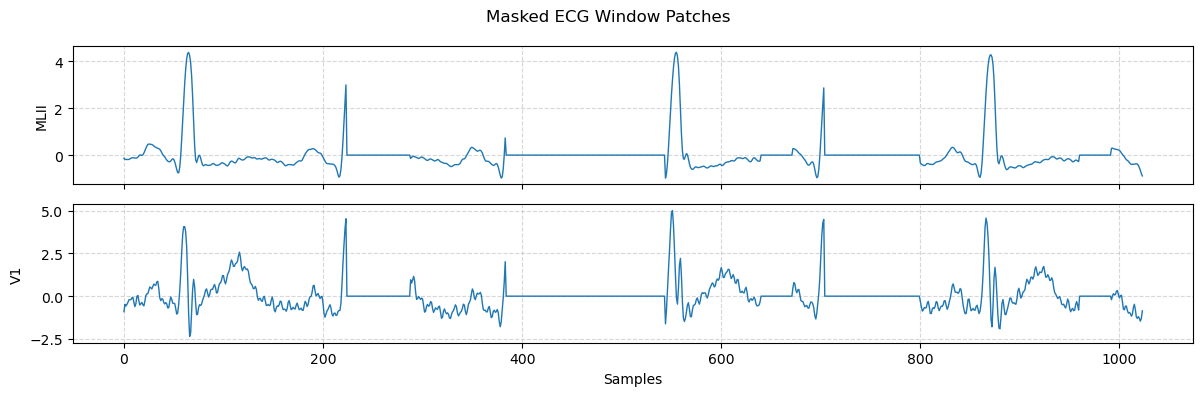

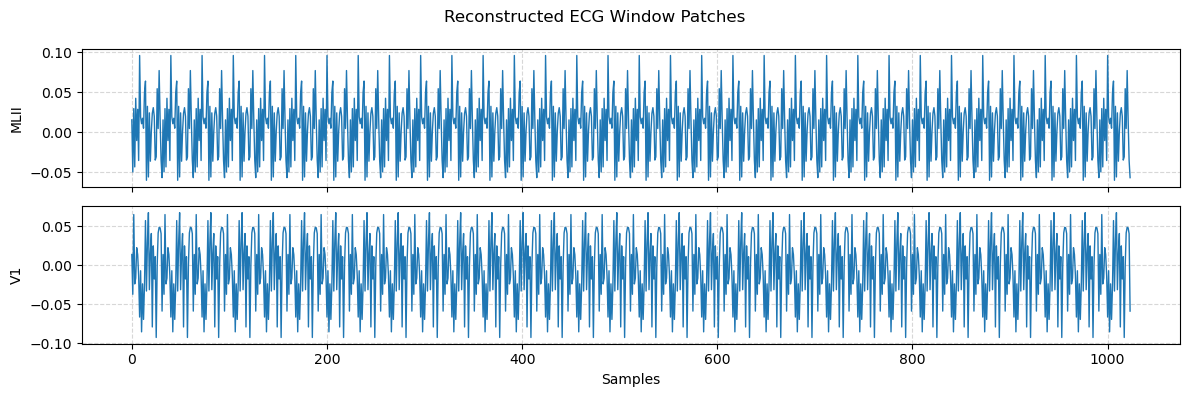

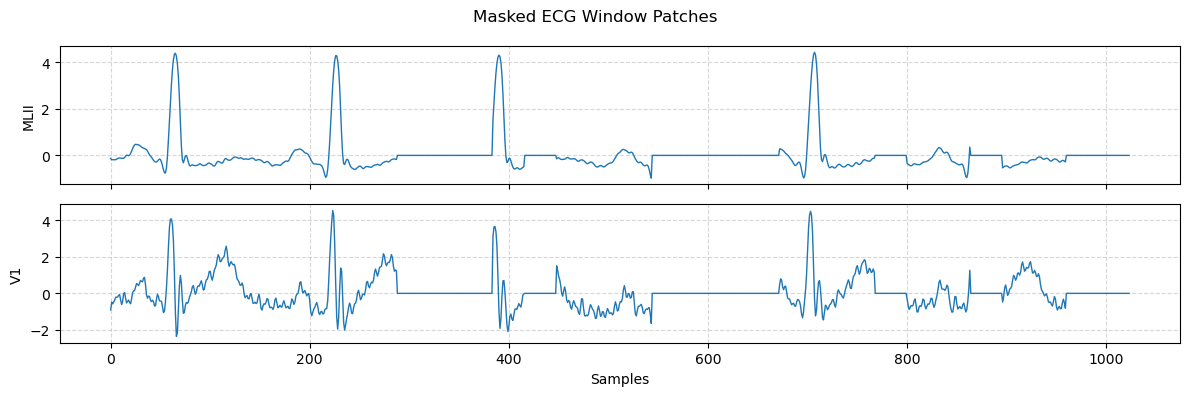

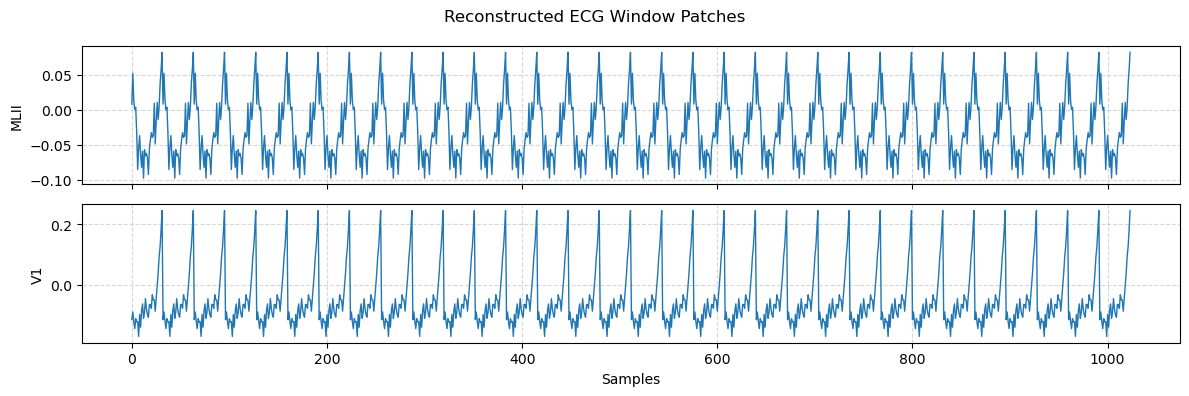

In [11]:
plot_ecg_window(labels[0], leads=['MLII', 'V1'], title='Original ECG Window Patches')
plot_ecg_window(x1_masked[0], leads=['MLII', 'V1'], title='Masked ECG Window Patches')
plot_ecg_window(recon1_signal[0], leads=['MLII', 'V1'], title='Reconstructed ECG Window Patches')
plot_ecg_window(x2_masked[0], leads=['MLII', 'V1'], title='Masked ECG Window Patches')
plot_ecg_window(recon2_signal[0], leads=['MLII', 'V1'], title='Reconstructed ECG Window Patches')

